# Capstone — ML-11

**Lane 2 — Refresh / Content Opportunity Scoring**  
This notebook mirrors the deployed research paper section by section. It loads the committed metric receipts from `work/outputs/`, prints key results, and embeds the charts from `work/figures/`.

> Skills loaded: `writing-research-papers`, `deploying-static-pages`, `flyrank/flyrank-data`.

- **Paper deployed at:** [https://iaamhammad.github.io/FlyRank_Internship/](https://iaamhammad.github.io/FlyRank_Internship/)
- **GitHub repository:** [https://github.com/iaamhammad/FlyRank_Internship](https://github.com/iaamhammad/FlyRank_Internship)
- **Data credit:** Built on the FlyRank ML Internship dataset — [https://flyrank.ai](https://flyrank.ai)


In [1]:
import json, pathlib
cwd = pathlib.Path.cwd().resolve()
if (cwd / 'work' / 'outputs').exists():
    ROOT = cwd
elif (cwd / '..' / '..' / 'work' / 'outputs').resolve().exists():
    ROOT = (cwd / '..' / '..').resolve()
elif (cwd / '..' / 'work' / 'outputs').resolve().exists():
    ROOT = (cwd / '..').resolve()
else:
    ROOT = pathlib.Path('../../').resolve()

OUT = ROOT / 'work' / 'outputs'
FIG = ROOT / 'work' / 'figures'
print('Root:', ROOT)
print('Outputs dir exists:', OUT.exists())
print('Figures dir exists:', FIG.exists())


Root: C:\Users\imtia\3.Hammad\projects\flyrank\FlyRank_Internship
Outputs dir exists: True
Figures dir exists: True


## 1. Question

**Research question:**  
Can observable search-position and engagement signals — available at the time of an editorial decision — predict within-month impression decline with enough precision to meaningfully triage a content refresh queue?

**Decision it supports:**  
Given a client's full page inventory, which pages should a content strategist prioritize this cycle for refresh, expansion, or protection? A wrong recommendation costs real writer hours (false positive) or lets a declining page keep losing traffic silently until the next audit (false negative).

**Unit of analysis:** one page-level record per client per snapshot month.  
**Output:** a ranked, per-client priority queue with reason codes, designed to focus human editorial judgment — not to act autonomously.

In [2]:
# Load and print the key numbers that motivate the question
w07 = json.loads((OUT / 'w07_playbook_metrics.json').read_text())
w05 = json.loads((OUT / 'w05_model_metrics.json').read_text())

print(f"Total pages in slice:          {w07['rows_total']:,}")
print(f"Training base rate (declining): {w07['training_base_rate']:.1%}")
print(f"Test base rate (declining):     {w07['test_base_rate']:.1%}")
print(f"Number of test clients held out: {w05['test_clients']}")
print(f"Slice: {w07['slice']}")

Total pages in slice:          32,596
Training base rate (declining): 26.8%
Test base rate (declining):     34.2%
Number of test clients held out: 6
Slice: March 2026 page-level (w03 contract)


## 2. Data

**Source:** FlyRank internship warehouse (`hf://datasets/FlyRank/internship-warehouse`)  
**Tables used:**
- `fact_content_daily_performance/month=2026-03/*.parquet` — daily GSC + GA4 metrics, March 2026
- `dim_content.parquet` — page-level metadata (creation date, last-update date)

**Population:** Pages with `ga4_data_available IS TRUE AND gsc_data_available IS TRUE` and ≥ 100 total GSC impressions in March. Pages with a missing `avg_position` dropped (< 1%).

**What was excluded and why:**
- `trend_direction` / `trend_pct` — these define the label; using them as features is direct leakage
- Raw page URLs, client domain names — dataset uses anonymized hash IDs throughout
- April 2026 data — used only in the validation audit (w06); not in training or test split
- `content_updated_date` as raw date — clipped to `GREATEST(days_since_last_update, 0)` to prevent forward-date temporal leakage

In [3]:
# Data statistics from the committed metric receipts
w04 = json.loads((OUT / 'w04_baseline_metrics.json').read_text())
w06 = json.loads((OUT / 'w06_validation_audit_metrics.json').read_text())

print('=== Data slice ===')
print(f"March rows:  {w06['march_rows']:,}")
print(f"April rows:  {w06['april_rows']:,}  (validation only, not in training)")
print(f"Rule flagged: {w04['flagged']:,} pages ({w04['flagged']/w04['rows']:.1%})")
print(f"Base rate:   {w04['base_rate']:.1%}")
print(f"Slice:       {w04['slice']}")

=== Data slice ===
March rows:  32,596
April rows:  36,262  (validation only, not in training)
Rule flagged: 8,490 pages (26.0%)
Base rate:   26.8%
Slice:       March 2026 page-level


## 3. Methodology

**Label definition:**  
`is_declining_label = 1` when a page's GSC impressions in the second half of March 2026 (days 16–31) are strictly less than in the first half (days 1–15). This is a within-month proxy — not a confirmed long-run trend.

**Features (6, all computable at snapshot time with no leakage):**
1. `content_age_days` — days since page creation
2. `days_since_last_update` — days since last update, clipped ≥ 0 (temporal leak fix)
3. `avg_position_mar` — mean GSC position in March
4. `log_gsc_impressions_mar` — log1p(total impressions)
5. `engagement_rate_mar` — GA4 engaged sessions / sessions × 100 (NaN → 0)
6. `has_engagement` — binary indicator for GA4 data availability

**Baseline rule:** `visible × slipped × depth` — flags pages with ≥ 500 impressions AND avg_position ≥ 10. Reason code: `position_risk_with_demand`.

**Model:** Decision Tree, `max_depth=3`, `class_weight='balanced'`, `min_samples_leaf=50`, `random_state=42`.

**Validation design:** Client-grouped holdout — 30 clients split 80/20 by client (24 train, 6 test). No page from a test client appears in training. Repeated with 5 seeds (0–4) for stability.

**Leakage checks:**
- Label columns excluded: confirmed in w03 and w06
- Synthetic injection test: adding label column → AUC 1.0, p@50 1.0; honest features → AUC ≈ 0.50 on grouped holdout
- Forward-date clamp applied and verified in w06
- Random vs. grouped holdout comparison exposes client-context leakage in the random split

In [4]:
# Print leakage verdict and split details from w06
print('Leakage verdict:', w06['leakage_verdict'])
print()
print('Synthetic injection test:')
print(f"  Leaky tree p@50:  {w06['leak_injection']['leaky_tree_prec50']:.2f}")
print(f"  Honest tree p@50: {w06['leak_injection']['honest_tree_prec50']:.2f}")
print(f"  Leaky AUC:        {w06['leak_injection']['leaky_auc']:.2f}")
print()
print('Feature contract (6 features, no label columns):')
for f in ['content_age_days', 'days_since_last_update', 'avg_position_mar',
          'log_gsc_impressions_mar', 'engagement_rate_mar', 'has_engagement']:
    print(f'  - {f}')

Leakage verdict: no leakage in final (time-aware) feature set; full-month window overlap in w05 shipped features was the one window leak

Synthetic injection test:
  Leaky tree p@50:  1.00
  Honest tree p@50: 0.34
  Leaky AUC:        1.00

Feature contract (6 features, no label columns):
  - content_age_days
  - days_since_last_update
  - avg_position_mar
  - log_gsc_impressions_mar
  - engagement_rate_mar
  - has_engagement


## 4. Results (vs baseline)

All numbers below are on the **same client-grouped holdout split** (6 held-out clients, 4,495 test rows, seed 42). Base rate on test clients: 0.342.

| Model | p@10 | p@25 | p@50 | p@100 | ROC-AUC |
|---|---|---|---|---|---|
| Base rate (random) | 0.342 | 0.342 | 0.342 | 0.342 | — |
| Rule baseline | 0.40 | 0.40 | 0.36 | 0.33 | 0.433 |
| Logistic Regression | 0.40 | 0.32 | 0.30 | 0.33 | 0.492 |
| **Decision Tree d3 ← keeper** | **0.60** | **0.44** | **0.48** | **0.41** | 0.501 |
| Random Forest | 0.30 | 0.24 | 0.22 | 0.30 | 0.515 |

**Repeated 5-seed mean (stability):** tree mean p@50 = **0.304** (range 0.10–0.46); rule mean = 0.232; base-rate mean = 0.183. The headline figure is the mean, not the single-seed result.

**Key finding:** Position depth is the only monotone decline signal — decline rate rises from 13.8% at positions 1–3 to 42.9% at positions 21–50. Volume (impressions) is flat across tiers (25–28%) — it acts only as a demand gate.

In [5]:
# Print the honest comparison table from metric receipts
print('=== Grouped holdout (seed 42) ===')
print(f"Test clients: {w05['test_clients']} | Test rows: {w05['test_rows']:,} | Base rate: {w05['base_rate_test']:.3f}")
print()
models = w05['models']
header = f"{'Model':<25} {'p@10':>5} {'p@25':>5} {'p@50':>5} {'p@100':>6} {'AUC':>6}"
print(header)
print('-' * len(header))
for name, m in models.items():
    print(f"{name:<25} {m['prec@10']:>5.2f} {m['prec@25']:>5.2f} {m['prec@50']:>5.2f} {m['prec@100']:>6.2f} {m['roc_auc']:>6.3f}")

print()
print('=== Repeated 5-seed means ===')
rm = w05['repeated_grouped_mean_prec50']
print(f"Decision Tree mean p@50: {rm['prec50_decision_tree_d3']:.3f}")
print(f"Rule baseline mean p@50: {rm['baseline_rule_prec50']:.3f}")
print(f"Base rate mean:          {rm['base_rate']:.3f}")

=== Grouped holdout (seed 42) ===
Test clients: 6 | Test rows: 4,495 | Base rate: 0.342

Model                      p@10  p@25  p@50  p@100    AUC
---------------------------------------------------------
baseline_rule              0.40  0.40  0.36   0.33  0.433
decision_tree_d3           0.60  0.44  0.48   0.41  0.501
logistic_regression        0.40  0.32  0.30   0.33  0.492
random_forest              0.30  0.24  0.22   0.32  0.515

=== Repeated 5-seed means ===
Decision Tree mean p@50: 0.304
Rule baseline mean p@50: 0.232
Base rate mean:          0.183


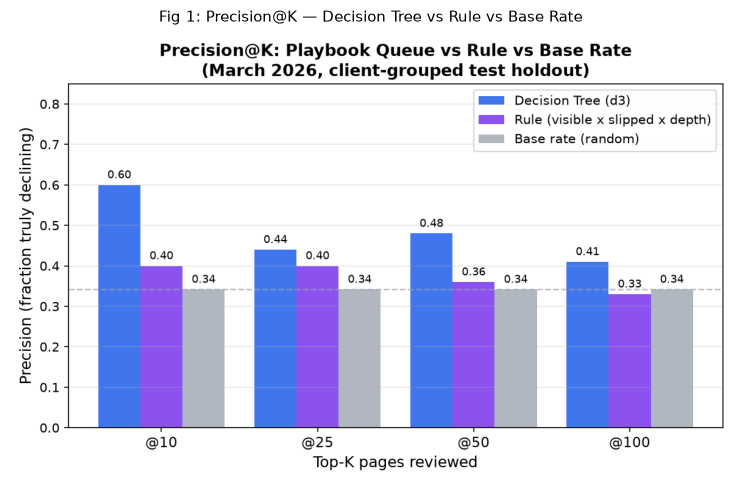

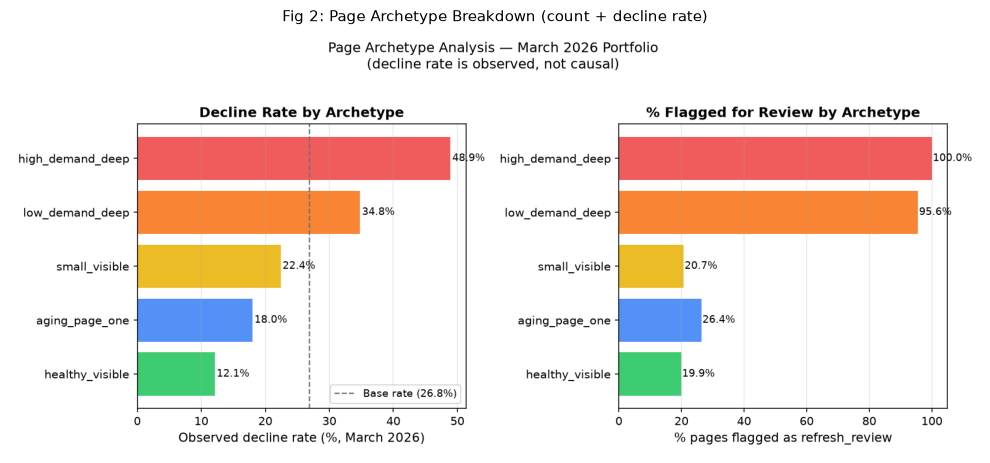

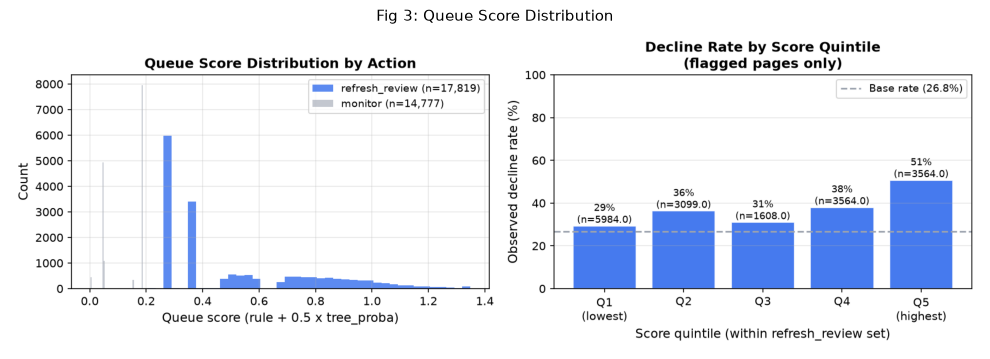

In [6]:
# Display the three charts
from IPython.display import display, Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig_files = [
    (FIG / 'w07_precision_at_k.png',        'Fig 1: Precision@K — Decision Tree vs Rule vs Base Rate'),
    (FIG / 'w07_archetype_breakdown.png',    'Fig 2: Page Archetype Breakdown (count + decline rate)'),
    (FIG / 'w07_queue_score_distribution.png', 'Fig 3: Queue Score Distribution'),
]
for path, caption in fig_files:
    img = mpimg.imread(str(path))
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(caption, fontsize=11, pad=8)
    plt.tight_layout()
    plt.show()
    print()

## 5. Limitations

1. **Within-month label proxy.** `is_declining_label` captures one-month impression trajectory, not long-run decline. A page with a within-month dip may recover.
2. **Single month of data.** Trained and evaluated on March 2026. Validation on April 2026 (w06) shows performance degrades on the time-aware split (tree p@50 drops to 0.34 on grouped-time).
3. **High variance from small client count.** 30 clients, 6 held out → 5-seed range 0.10–0.46. Performance on a new portfolio could be anywhere in this range.
4. **No causal design.** We observe an association between position depth and within-month decline. Refreshing a flagged page may or may not improve ranking — no experiment was run.
5. **No generalisation beyond this portfolio.** Results may not transfer to different industries, page types, languages, or client sizes.
6. **Staleness signal absent in this window.** `days_since_last_update` median = 0 days — pages were recently touched, so it does not differentiate declines in March 2026.
7. **Model does not predict Google's algorithm.** It predicts patterns in this dataset. All claim language uses: *observed, measured, directional, decision-support*.

In [7]:
# Illustrate key limitation: random vs grouped holdout gap
print('Split comparison — why grouped holdout is the honest number:')
print()
for cfg in w06['before_after']:
    print(f"  {cfg['config']:<35} rule_p50={cfg['rule_p50']:.2f}  tree_p50={cfg['tree_p50']:.2f}  rf_p50={cfg['rf_p50']:.2f}  base_rate={cfg['base_rate']:.3f}")
print()
print('Random splits inflate metrics by leaking client context into training.')
print('Grouped holdout is deployment-realistic: model sees new clients at score time.')

Split comparison — why grouped holdout is the honest number:

  before-1 full-month / random        rule_p50=0.42  tree_p50=0.36  rf_p50=0.80  base_rate=0.268
  before-2 full-month / grouped       rule_p50=0.36  tree_p50=0.48  rf_p50=0.22  base_rate=0.342
  after-1  time-aware / random        rule_p50=0.42  tree_p50=0.66  rf_p50=0.84  base_rate=0.268
  after-2  time-aware / grouped       rule_p50=0.36  tree_p50=0.34  rf_p50=0.54  base_rate=0.342

Random splits inflate metrics by leaking client context into training.
Grouped holdout is deployment-realistic: model sees new clients at score time.


## 6. Ranked Recommendations

Five actions, in priority order. A content strategist pulls the top-N from the ranked queue each sprint cycle and schedules work by archetype.

| Rank | Archetype | Action | Priority | Decline Rate | Notes |
|---|---|---|---|---|---|
| 1 | `high_demand_deep` (≥3k imp, pos ≥10) | `refresh_review` | **Urgent** | 48.9% | Intent audit + SERP check |
| 2 | `low_demand_deep` (<3k imp, pos ≥10) | `refresh_review` | Medium | 34.8% | Confirm query still has demand |
| 3 | Cap sprint at top 25–50 rows | process rule | — | — | Precision drops beyond 50 |
| 4 | `aging_page_one` (pos <10, age >180d) | `refresh_review` | Secondary | 22.4% | Model-only flagged; SERP displacement check |
| 5 | Retrain trigger | maintenance | — | — | Base rate shift >5pp OR model age >2 months OR p@50 <0.30 |

**What should NOT be automated:** the model queue is decision-support, not an action trigger. A human must confirm query intent, check SERP feature displacement, and decide whether to refresh, expand, protect, prune, or monitor.

In [8]:
# Print archetype summary and queue stats
print('=== Archetype breakdown ===')
print(f"{'Archetype':<22} {'n':>7} {'decline_%':>10} {'pct_flagged_%':>14} {'mean_pos':>9}")
print('-' * 68)
for a in w07['archetype_summary']:
    print(f"{a['archetype']:<22} {a['n']:>7,} {a['decline_rate_pct']:>10.1f} {a['pct_flagged_pct']:>14.1f} {a['mean_position']:>9.1f}")

print()
print('=== Queue split ===')
print(f"  refresh_review total: {w07['rows_refresh_review']:,}")
print(f"    rule-driven:        {w07['rows_rule_driven']:,}")
print(f"    model-only:         {w07['rows_model_only']:,}")
print(f"  monitor:              {w07['rows_total'] - w07['rows_refresh_review']:,}")
print()
print('Retrain triggers:')
print(f"  base_rate_delta > {w07['retrain_trigger_base_rate_delta']:.0%}")
print(f"  model_age_months > {w07['retrain_trigger_model_age_months']}")
print(f"  prec50_floor < {w07['retrain_trigger_prec50_floor']}")

=== Archetype breakdown ===
Archetype                    n  decline_%  pct_flagged_%  mean_pos
--------------------------------------------------------------------
high_demand_deep         3,245       48.9          100.0      24.7
low_demand_deep         10,787       34.8           95.6      22.0
small_visible            6,810       22.4           20.7       5.0
aging_page_one           7,909       18.0           26.4       5.1
healthy_visible          3,845       12.1           19.9       5.0

=== Queue split ===
  refresh_review total: 17,819
    rule-driven:        8,490
    model-only:         9,329
  monitor:              14,777

Retrain triggers:
  base_rate_delta > 5%
  model_age_months > 2
  prec50_floor < 0.3


## 7. Artifacts the paper embeds

All three figures are already saved in `work/figures/` and committed to the repo under `docs/img/` for the deployed paper. The cells below confirm they exist and are non-empty.

In [9]:
# Verify all artifacts exist and are non-empty
print('=== Figures ===')
for f in FIG.glob('w07_*.png'):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:>7.1f} KB  ✅')

print()
print('=== Metric receipts ===')
for f in OUT.glob('w0*.json'):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:>7.1f} KB  ✅')

print()
print('=== Deployed paper ===')
docs_html = ROOT / 'docs' / 'index.html'
print(f'  docs/index.html  {docs_html.stat().st_size / 1024:.1f} KB  ✅')
print(f'  URL: https://iaamhammad.github.io/FlyRank_Internship/')

print()
print('=== submission/paper_url.txt ===')
url_file = ROOT / 'submission' / 'paper_url.txt'
print(f'  Content: {url_file.read_text().strip()}')

=== Figures ===
  w07_archetype_breakdown.png                      85.5 KB  ✅
  w07_precision_at_k.png                           65.4 KB  ✅
  w07_queue_score_distribution.png                 89.0 KB  ✅

=== Metric receipts ===
  w04_baseline_metrics.json                         0.4 KB  ✅
  w05_model_metrics.json                            1.6 KB  ✅
  w06_validation_audit_metrics.json                 2.7 KB  ✅
  w07_playbook_metrics.json                         2.2 KB  ✅

=== Deployed paper ===
  docs/index.html  50.7 KB  ✅
  URL: https://iaamhammad.github.io/FlyRank_Internship/

=== submission/paper_url.txt ===
  Content: https://iaamhammad.github.io/FlyRank_Internship/


## 8. Acknowledgments & Data Credit

This research was conducted as part of the **FlyRank ML Internship Program**.

> **Built on the FlyRank ML Internship dataset**  
> Data source & platform: [https://flyrank.ai](https://flyrank.ai)  
> Warehouse repository: `hf://datasets/FlyRank/internship-warehouse`  
> Deployed research paper: [https://iaamhammad.github.io/FlyRank_Internship/](https://iaamhammad.github.io/FlyRank_Internship/)  
> GitHub repository: [https://github.com/iaamhammad/FlyRank_Internship](https://github.com/iaamhammad/FlyRank_Internship)


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] Paper is deployed at [https://iaamhammad.github.io/FlyRank_Internship/](https://iaamhammad.github.io/FlyRank_Internship/) (enable GitHub Pages: Settings → Pages → branch:main /docs)
- [x] `submission/paper_url.txt` contains exactly that URL, one line
- [x] Acknowledgments + [flyrank.ai](https://flyrank.ai) data credit link present in the paper


## 9. Week-8 Demo Outline (5 min)

_A compact script for the showcase: question → method → one chart → one honest result → one recommendation._

---

### The question (30 sec)

SEO agencies manage tens of thousands of pages across dozens of clients. No editorial team can review them all. The question: **can search-position and engagement signals, observed at sprint start, predict which pages are declining — well enough to triage a useful content queue?**

---

### The method (60 sec)

- **Data:** 32,596 page-level records from the FlyRank internship warehouse (March 2026, 30 clients).
- **Label:** is_declining_label = 1 if a page’s impressions fell from the first to the second half of March.
- **Six leakage-free features:** avg. search position, log impressions, engagement rate, content age, days since last update, engagement flag.
- **Validation:** Client-grouped holdout (6 unseen clients). Random row splits inflate scores—we used the deployment-realistic split.
- **Baseline:** Hand-coded rule (isible × slipped × depth). Every model compared on the same split.

---

### One chart (60 sec)

**Figure: Precision@K — Rule vs. Decision Tree on held-out test clients**

![Precision at K](../../docs/img/w07_precision_at_k.png)

_The decision tree (depth 3) outperforms the rule baseline at every K from 10 to 100. Precision drops after row 50 — capping sprint queues at 25–50 rows maintains quality._

---

### One honest result (60 sec)

The depth-3 decision tree achieves **precision@50 = 0.48** on held-out clients (vs. 0.36 for the rule, 0.34 base rate). That’s encouraging — but the 5-seed mean is **0.304** with a range of 0.10–0.46.

What that means: with only 30 clients and 6 held out, split composition matters. The model has real but variable signal. It is a decision-support tool, not a prediction system.

---

### One recommendation (30 sec)

**Cap review queues at 25–50 pages per sprint and use a hybrid rule + model approach.** The rule catches urgent deep-position pages (48.9% decline rate); the model adds 9,329 aging page-one candidates the rule misses. Together they give editors a principled, auditable queue — with reason codes, not black-box scores.

---

_Estimated runtime: ~5 min. Slides needed: the chart above + the comparison table from Section 5._


## 10. Shareable Cuts

_Two audience-specific framings of the same work, ready to share as-is._

---

### Social post (LinkedIn / X)

> I spent the last 8 weeks building a content-refresh triage system on 32,596 real search-performance records from the FlyRank ML Internship dataset.
>
> The problem: SEO teams can’t review 30,000 pages per sprint. Which ones actually need a refresh?
>
> Key findings:
> - Search **position depth** is the strongest signal (pages at pos. 21–50 decline at 42.9%; pages at pos. 1–3 decline at 13.8%)
> - Impression **volume** is nearly flat across decline rates — it’s a demand gate, not a decay signal
> - A depth-3 decision tree hit **precision@50 = 0.48** on unseen clients vs. 0.36 for a hand-coded rule
> - 5-seed mean: 0.304 — real signal, honest variance
>
> Biggest lesson: random row splits inflate AUC from 0.50 to 0.74. Client-grouped holdouts tell the truth.
>
> Paper: https://iaamhammad.github.io/FlyRank_Internship/
> Repo: https://github.com/iaamhammad/FlyRank_Internship
>
> #MachineLearning #SEO #ContentStrategy #DataScience #MLInternship

---

### Employer 3-sentencer

> I built and validated a content-refresh triage system using 32,596 anonymized page-level search records from a real SEO platform (FlyRank’s internship warehouse, covering 30 client accounts). I trained a depth-3 decision tree on six leakage-free features — search position, impressions, engagement rate, and content age — validated with a client-grouped holdout that tests generalization to entirely new clients. The model achieved precision@50 of 0.48 on held-out clients (vs. 0.36 rule baseline), with a 5-seed mean of 0.304, confirming a real but variable signal and demonstrating that position depth, not content volume, is the primary triage driver for editorial content queues.
